# Сверточные нейронные сети

In [1]:
# !python -m pip install scikit-learn

In [2]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torchvision.transforms.v2 as T
from IPython.display import clear_output
from PIL import Image
from matplotlib import cm
from time import perf_counter
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
import os

warnings.filterwarnings('ignore')

# plt.rc('font', size=30)

/home/iasudakov/miniconda3/envs/opdlm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Загрузка изображения

Загрузим изображение из интернета, например, ....

In [3]:
!wget "https://i.scdn.co/image/ab67616d0000b2734864b69b7aff79e082e62233" -O ye.jpg

--2026-09-28 23:27:04--  https://i.scdn.co/image/ab67616d0000b2734864b69b7aff79e082e62233
Resolving i.scdn.co (i.scdn.co)... 2a02:26f0:6600::17c4:ec79, 2a02:26f0:6600::17c4:ec48, 2a02:26f0:6600::17c4:ec51
Connecting to i.scdn.co (i.scdn.co)|2a02:26f0:6600::17c4:ec79|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 137983 (135K) [image/jpeg]
Saving to: ‘ye.jpg’

ye.jpg              100%[===================>] 134.75K  --.-KB/s    in 0.03s   

2026-09-28 23:27:04 (5.09 MB/s) - ‘ye.jpg’ saved [137983/137983]



## Чтение изображения

In [4]:
img = Image.open('ye.jpg')

In [5]:
img.format

'JPEG'

In [6]:
img.size

(640, 640)

In [7]:
img.mode

'RGB'

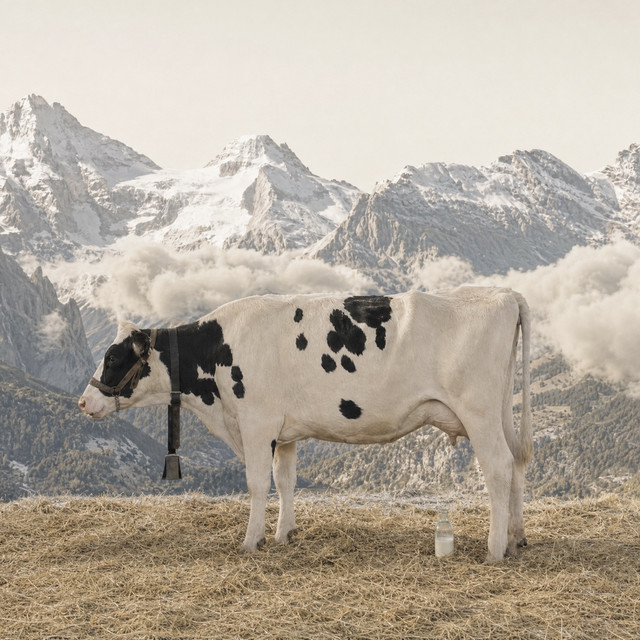

In [8]:
img

## Матричное представление

In [9]:
img_matrix = T.ToTensor()(img)

In [10]:
img_matrix.shape

torch.Size([3, 640, 640])

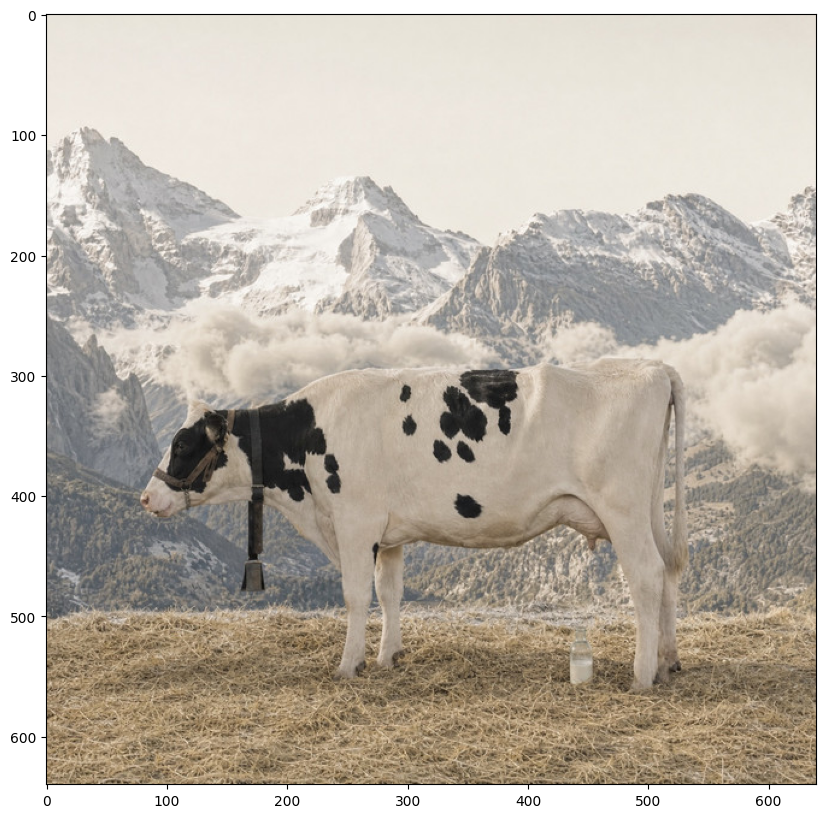

In [11]:
plt.figure(figsize=(20, 10))
plt.imshow(img_matrix.permute(1, 2, 0))
plt.show()

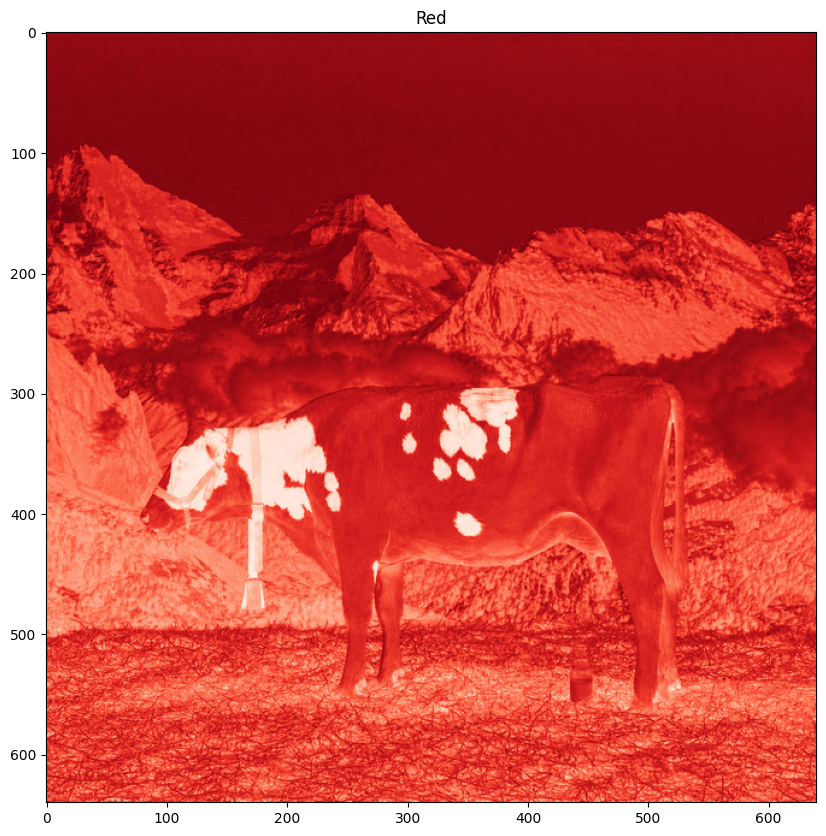

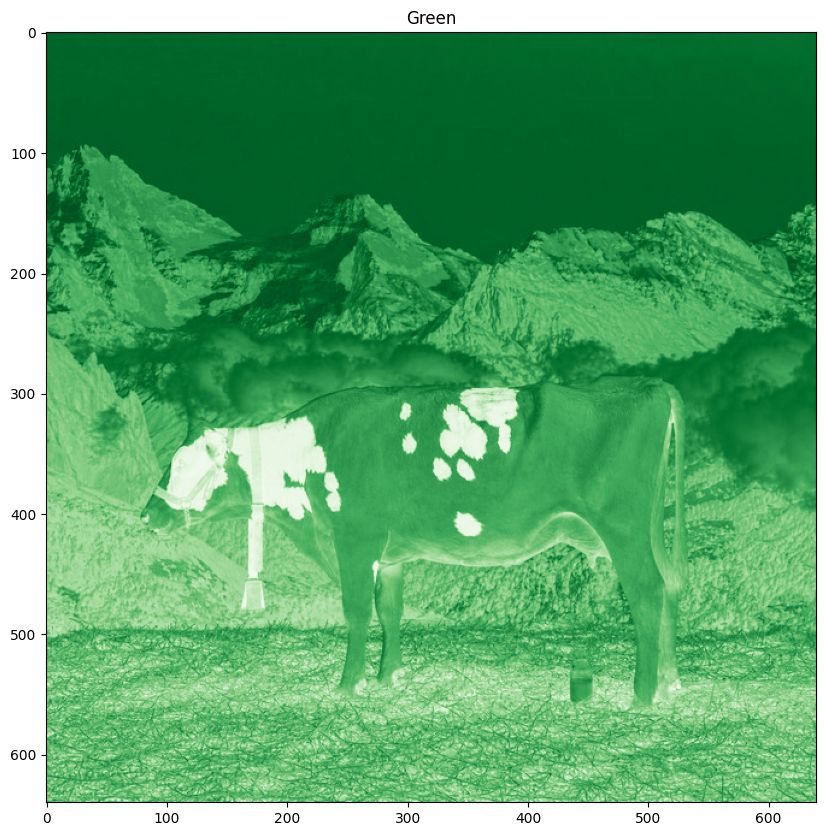

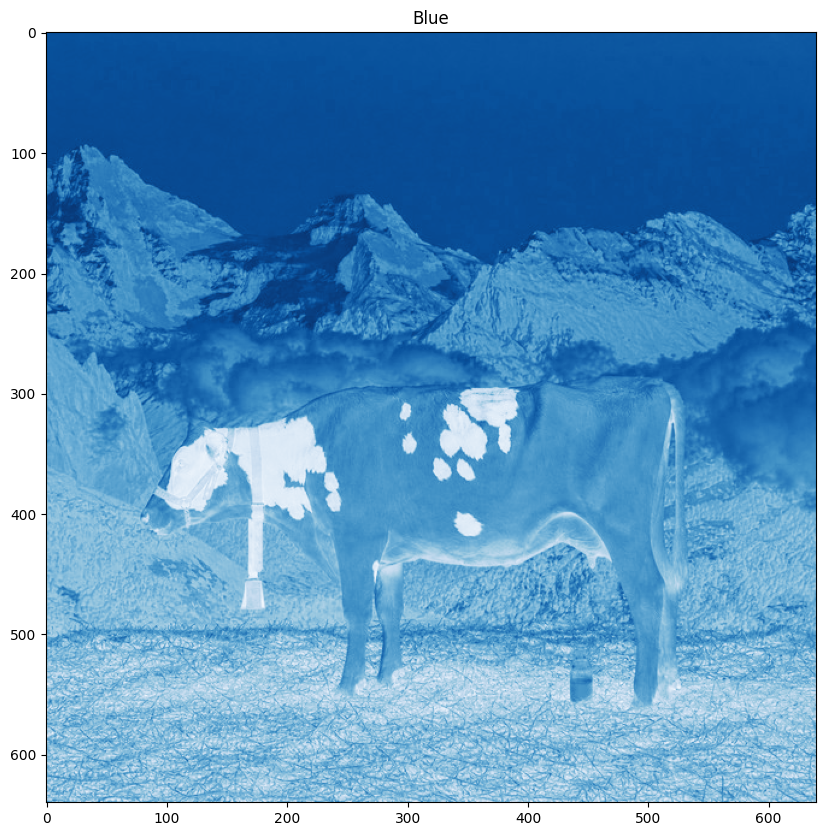

In [12]:
for i, (cmap, color) in enumerate(
    zip(
        [cm.Reds, cm.Greens, cm.Blues],
        ['Red', 'Green', 'Blue']
    )
):
    plt.figure(figsize=(20, 10))
    plt.imshow(img_matrix[i], cmap=cmap)
    plt.title(color)
    plt.show()

In [13]:
img_matrix.min(), img_matrix.max()

(tensor(0.0039), tensor(1.))

In [14]:
img_matrix

tensor([[[0.9059, 0.9059, 0.9098,  ..., 0.8941, 0.8980, 0.8980],
         [0.9059, 0.9098, 0.9098,  ..., 0.8980, 0.8980, 0.8980],
         [0.9098, 0.9098, 0.9098,  ..., 0.8980, 0.8980, 0.8980],
         ...,
         [0.6275, 0.4706, 0.4863,  ..., 0.6353, 0.6392, 0.6863],
         [0.6314, 0.5373, 0.5529,  ..., 0.5843, 0.5725, 0.5686],
         [0.6745, 0.8000, 0.7294,  ..., 0.5608, 0.5176, 0.4314]],

        [[0.8902, 0.8902, 0.8941,  ..., 0.8667, 0.8706, 0.8706],
         [0.8902, 0.8941, 0.8941,  ..., 0.8706, 0.8706, 0.8706],
         [0.8941, 0.8941, 0.8941,  ..., 0.8706, 0.8706, 0.8706],
         ...,
         [0.5529, 0.3961, 0.4039,  ..., 0.5529, 0.5569, 0.6078],
         [0.5647, 0.4706, 0.4784,  ..., 0.5059, 0.5059, 0.5020],
         [0.6118, 0.7333, 0.6627,  ..., 0.4980, 0.4549, 0.3725]],

        [[0.8549, 0.8549, 0.8588,  ..., 0.8275, 0.8314, 0.8314],
         [0.8549, 0.8588, 0.8588,  ..., 0.8314, 0.8314, 0.8314],
         [0.8588, 0.8588, 0.8588,  ..., 0.8314, 0.8314, 0.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.29764637..1.3862472].


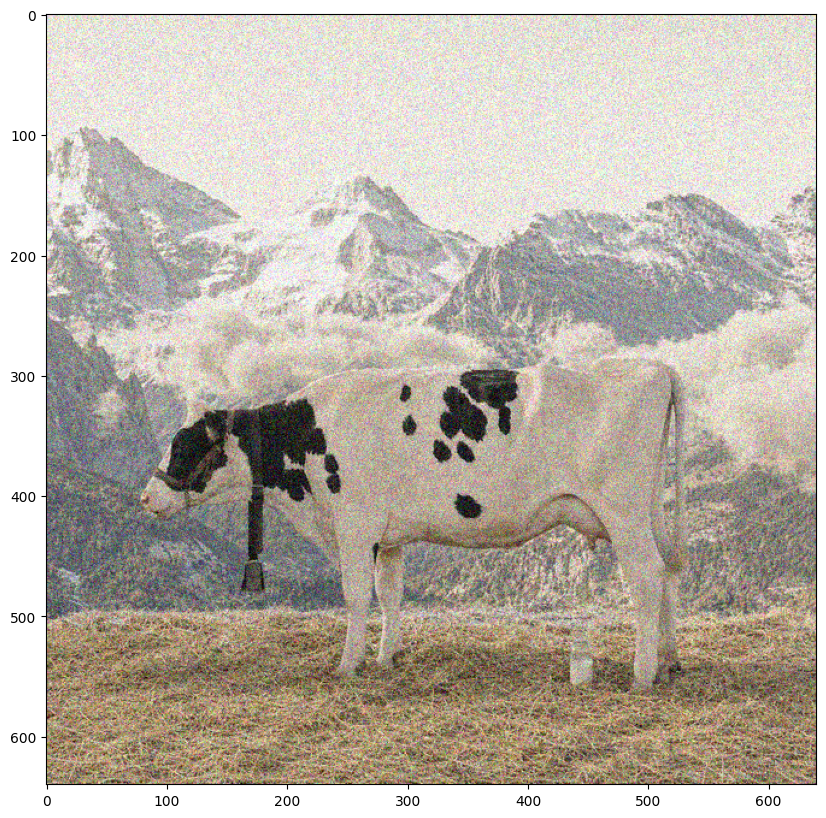

In [15]:
noise_photo = img_matrix + torch.randn_like(img_matrix) * 0.1

plt.figure(figsize=(20, 10))
plt.imshow(noise_photo.permute(1, 2, 0))
plt.show()

## Свертка

Свертка в `PyTorch` представлена модулем `nn.Conv2d` со следующими параметрами:

- in_channels (int) – Количество каналов во входном изображении

- out_channels (int) – Количество каналов в выходном изображении

- kernel_size (int or tuple) – Размер ядра свертки

- stride (int or tuple, optional) – Страйд (шаг ядра свертки). По умолчанию: 1

- padding (int, tuple or str, optional) – Размер паддинга. По умолчанию: 0

- padding_mode (string, optional) – 'zeros', 'reflect', 'replicate' or 'circular'. По умолчанию: 'zeros'

- dilation (int or tuple, optional) – Дилейшн (шаг между элементами внутри ядра). По умолчанию: 1

- bias (bool, optional) – добавлять ли обучаемый сдвиг. По умолчанию: True

https://github.com/vdumoulin/conv_arithmetic

In [16]:
conv1 = nn.Conv2d(
    in_channels=3,
    out_channels=10,
    kernel_size=3,
    stride=1,
    padding=0,
    dilation=1,
    groups=1,
    bias=True,
    padding_mode='zeros',
    device=None,
    dtype=None,
)

In [17]:
(1200 + 2 * 0 - 1 * 2 - 1) / 1 + 1

1198.0

$\begin{aligned} & H_{\text {out }}=\left\lfloor\frac{H_{\text {in }}+2 \times \text { padding }[0]-\operatorname{dilation}[0] \times(\text { kernel size }[0]-1)-1}{\text { stride }[0]}+1\right\rfloor \\ & W_{\text {out }}=\left\lfloor\frac{W_{\text {in }}+2 \times \text { padding }[1]-\operatorname{dilation}[1] \times(\text { kernel size }[1]-1)-1}{\operatorname{stride}[1]}+1\right\rfloor\end{aligned}$

In [18]:
img_tensor = img_matrix.unsqueeze(0)

In [19]:
img_tensor.shape

torch.Size([1, 3, 640, 640])

In [20]:
output = conv1(img_tensor)

In [21]:
output.shape

torch.Size([1, 10, 638, 638])

In [22]:
conv2 = nn.Conv2d(
    in_channels=3,
    out_channels=10,
    kernel_size=3,
    padding=1
)

In [23]:
output = conv2(img_tensor)

In [24]:
output.shape

torch.Size([1, 10, 640, 640])

In [25]:
conv2.weight

Parameter containing:
tensor([[[[-0.1710, -0.0737,  0.0591],
          [ 0.0702, -0.0182,  0.1572],
          [ 0.1806,  0.0396,  0.0441]],

         [[-0.1890, -0.1642,  0.1314],
          [-0.1553,  0.0321,  0.0634],
          [-0.1741,  0.1426, -0.1045]],

         [[ 0.0392, -0.0933,  0.0829],
          [-0.0078,  0.1767, -0.0946],
          [ 0.0743, -0.0347, -0.1917]]],


        [[[-0.1914,  0.0640, -0.1546],
          [-0.1047,  0.0040, -0.1001],
          [-0.0563,  0.1102,  0.1311]],

         [[ 0.0845,  0.0138, -0.0542],
          [-0.0068, -0.0621,  0.0706],
          [-0.1014, -0.0926, -0.0092]],

         [[-0.0778,  0.1771, -0.0700],
          [ 0.0430, -0.1833,  0.1751],
          [ 0.1838, -0.1382,  0.0167]]],


        [[[-0.0745,  0.0737, -0.1524],
          [ 0.1551,  0.1718, -0.0629],
          [ 0.1109, -0.0986, -0.1257]],

         [[-0.1454,  0.1642, -0.1557],
          [-0.1427, -0.0920, -0.0012],
          [ 0.1825, -0.1586,  0.1720]],

         [[ 0.1140, -0

In [26]:
conv2.weight.shape

torch.Size([10, 3, 3, 3])

In [27]:
conv2.bias.shape

torch.Size([10])

### im2col vs conv2d

In [28]:
x = torch.arange(1, 25, dtype=torch.float32).reshape(2, 1, 3, 4)

conv = torch.nn.Conv2d(1, 6, 3, bias=False)

In [29]:
x

tensor([[[[ 1.,  2.,  3.,  4.],
          [ 5.,  6.,  7.,  8.],
          [ 9., 10., 11., 12.]]],


        [[[13., 14., 15., 16.],
          [17., 18., 19., 20.],
          [21., 22., 23., 24.]]]])

In [30]:
x.shape, conv.weight.shape

(torch.Size([2, 1, 3, 4]), torch.Size([6, 1, 3, 3]))

In [31]:
import torch.nn.functional as F

x_unfold = F.unfold(x, kernel_size=(3, 3), stride=1)  # (2, 9, 2)

In [32]:
x_unfold

tensor([[[ 1.,  2.],
         [ 2.,  3.],
         [ 3.,  4.],
         [ 5.,  6.],
         [ 6.,  7.],
         [ 7.,  8.],
         [ 9., 10.],
         [10., 11.],
         [11., 12.]],

        [[13., 14.],
         [14., 15.],
         [15., 16.],
         [17., 18.],
         [18., 19.],
         [19., 20.],
         [21., 22.],
         [22., 23.],
         [23., 24.]]])

In [33]:
y = torch.matmul(conv.weight.data.view(-1, 9), x_unfold).view(2, 6, 1, 2)

In [34]:
y

tensor([[[[ -5.0194,  -5.4031]],

         [[ -4.4576,  -5.1613]],

         [[ -5.3295,  -5.6702]],

         [[  0.9013,   0.7981]],

         [[ -2.0904,  -2.5315]],

         [[ -2.5406,  -3.1241]]],


        [[[ -9.6245, -10.0082]],

         [[-12.9018, -13.6055]],

         [[ -9.4186,  -9.7594]],

         [[ -0.3372,  -0.4404]],

         [[ -7.3826,  -7.8236]],

         [[ -9.5429, -10.1265]]]])

In [35]:
y2 = conv(x)
y2

tensor([[[[ -5.0194,  -5.4031]],

         [[ -4.4576,  -5.1613]],

         [[ -5.3295,  -5.6702]],

         [[  0.9013,   0.7981]],

         [[ -2.0904,  -2.5315]],

         [[ -2.5406,  -3.1241]]],


        [[[ -9.6245, -10.0082]],

         [[-12.9018, -13.6055]],

         [[ -9.4186,  -9.7594]],

         [[ -0.3372,  -0.4404]],

         [[ -7.3826,  -7.8236]],

         [[ -9.5429, -10.1265]]]], grad_fn=<ConvolutionBackward0>)

## Пулинг

Пулинг представлен в модуле `torch.nn`, в основном будем использовать `MaxPool2d` и `AvgPool2d`.

Параметры:

- kernel_size – размер окошка

- stride – страйд окошка. По умолчанию равен kernel_size

- padding – сколько нулевого паддинга добавлять по краям. По умолчанию: 0.

In [36]:
img_tensor = torch.randint(0, 10, size=(10, 10), dtype=torch.float32).unsqueeze(0)

In [37]:
img_tensor

tensor([[[2., 2., 1., 3., 6., 7., 9., 7., 7., 4.],
         [2., 5., 2., 5., 7., 3., 2., 5., 1., 2.],
         [1., 9., 8., 0., 0., 8., 2., 7., 7., 8.],
         [1., 6., 5., 0., 5., 8., 3., 1., 2., 9.],
         [5., 9., 0., 7., 9., 4., 5., 8., 0., 1.],
         [0., 1., 1., 8., 2., 4., 3., 5., 8., 1.],
         [5., 5., 9., 7., 7., 7., 9., 6., 9., 0.],
         [0., 6., 3., 3., 8., 1., 1., 2., 3., 3.],
         [1., 3., 5., 9., 2., 8., 2., 8., 7., 8.],
         [8., 8., 9., 0., 4., 2., 7., 2., 3., 7.]]])

In [38]:
pooling1 = nn.MaxPool2d(kernel_size=2)

In [39]:
pooling1(img_tensor)

tensor([[[5., 5., 7., 9., 7.],
         [9., 8., 8., 7., 9.],
         [9., 8., 9., 8., 8.],
         [6., 9., 8., 9., 9.],
         [8., 9., 8., 8., 8.]]])

In [40]:
pooling2 = nn.AvgPool2d(kernel_size=2)

In [41]:
pooling2(img_tensor)

tensor([[[2.7500, 2.7500, 5.7500, 5.7500, 3.5000],
         [4.2500, 3.2500, 5.2500, 3.2500, 6.5000],
         [3.7500, 4.0000, 4.7500, 5.2500, 2.5000],
         [4.0000, 5.5000, 5.7500, 4.5000, 3.7500],
         [5.0000, 5.7500, 4.0000, 4.7500, 6.2500]]])

## Подготовка данных

In [42]:
%pip install -q kagglehub

from pathlib import Path
import kagglehub

# Downloads and extracts the dataset; later runs reuse the cached files.
dataset_root = Path(kagglehub.dataset_download(
    'lantian773030/pokemonclassification'
)) / 'PokemonData'
print(f'Dataset directory: {dataset_root}')

Note: you may need to restart the kernel to use updated packages.
Dataset directory: /home/iasudakov/.cache/kagglehub/datasets/lantian773030/pokemonclassification/versions/1/PokemonData


In [43]:
sorted(path.name for path in dataset_root.iterdir())[:10]

['Abra',
 'Aerodactyl',
 'Alakazam',
 'Alolan Sandslash',
 'Arbok',
 'Arcanine',
 'Articuno',
 'Beedrill',
 'Bellsprout',
 'Blastoise']

In [44]:
import glob

bad_images = glob.glob(str(dataset_root / '*' / '*.svg'))

In [45]:
import os
for bad_image in bad_images:
    os.remove(bad_image)

In [46]:
class PokemonDataset(Dataset):
    SPLIT_RANDOM_SEED = 42
    TEST_SIZE = 0.25

    def __init__(self, root, train=True, load_to_ram=True, transform=None):
        super().__init__()
        self.root = root
        self.train = train
        self.load_to_ram = load_to_ram
        self.transform = transform
        self.to_tensor = T.ToTensor()
        self.all_files = []
        self.all_labels = []
        self.images = []

        self.classes = sorted(os.listdir(self.root))
        for i, class_name in tqdm(enumerate(self.classes), total=len(self.classes)):
            files = sorted(os.listdir(os.path.join(self.root, class_name)))
            train_files, test_files = train_test_split(files, random_state=self.SPLIT_RANDOM_SEED + i,
                                                       test_size=self.TEST_SIZE)
            if self.train:
                self.all_files += train_files
                self.all_labels += [i] * len(train_files)
                if self.load_to_ram:
                    self.images += self._load_images(train_files, i)

            else:
                self.all_files += test_files
                self.all_labels += [i] * len(test_files)
                if self.load_to_ram:
                    self.images += self._load_images(test_files, i)

    def _load_images(self, image_files, label):
        images = []
        for filename in image_files:
            image = Image.open(os.path.join(self.root, self.classes[label], filename)).convert('RGB')
            images += [image]

        return images

    def __len__(self):
        return len(self.all_files)

    def __getitem__(self, item):
        label = self.all_labels[item]
        if self.load_to_ram:
            image = self.images[item]
        else:
            filename = self.all_files[item]
            image = Image.open(os.path.join(self.root, self.classes[label], filename)).convert('RGB')

        if self.transform is not None:
            image = self.transform(image)

        return image, label

In [47]:
train_dataset = PokemonDataset(root=dataset_root, train=True, load_to_ram=False)

100%|██████████| 150/150 [00:00<00:00, 2473.84it/s]


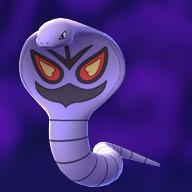

In [48]:
image, label = train_dataset[101]
image

In [49]:
train_dataset.classes[label]

'Arbok'

In [50]:
normalize = T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

test_transform = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(),
    normalize,
])

In [51]:
train_dataset = PokemonDataset(root=dataset_root, train=True, load_to_ram=True, transform=test_transform)
test_dataset = PokemonDataset(root=dataset_root, train=False, load_to_ram=True, transform=test_transform)

100%|██████████| 150/150 [00:04<00:00, 32.88it/s]


In [52]:
print(f'Число классов: {len(train_dataset.classes)}')

Число классов: 150


In [53]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, pin_memory=True, num_workers=2)

In [54]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda', index=0)

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import clear_output
from tqdm.auto import tqdm


sns.set_style('whitegrid')
plt.rcParams.update({'font.size': 15})


def plot_losses(train_losses, test_losses, train_accuracies, test_accuracies):
    clear_output()
    fig, axs = plt.subplots(1, 2, figsize=(13, 4))
    axs[0].plot(range(1, len(train_losses) + 1), train_losses, label='train')
    axs[0].plot(range(1, len(test_losses) + 1), test_losses, label='test')
    axs[0].set_ylabel('loss')

    axs[1].plot(range(1, len(train_accuracies) + 1), train_accuracies, label='train')
    axs[1].plot(range(1, len(test_accuracies) + 1), test_accuracies, label='test')
    axs[1].set_ylabel('accuracy')

    for ax in axs:
        ax.set_xlabel('epoch')
        ax.legend()

    plt.show()

In [56]:
def training_epoch(model, optimizer, criterion, train_loader, tqdm_desc):
    train_loss, train_accuracy = 0.0, 0.0
    model.train()
    for images, labels in tqdm(train_loader, desc=tqdm_desc):
        images = images.to(device)  # images: batch_size x num_channels x height x width
        labels = labels.to(device)  # labels: batch_size

        optimizer.zero_grad()
        logits = model(images)  # logits: batch_size x num_classes
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.shape[0]
        train_accuracy += (logits.argmax(dim=1) == labels).sum().item()

    train_loss /= len(train_loader.dataset)
    train_accuracy /= len(train_loader.dataset)
    return train_loss, train_accuracy


@torch.no_grad()
def validation_epoch(model, criterion, test_loader, tqdm_desc):
    test_loss, test_accuracy = 0.0, 0.0
    model.eval()
    for images, labels in tqdm(test_loader, desc=tqdm_desc):
        images = images.to(device)  # images: batch_size x num_channels x height x width
        labels = labels.to(device)  # labels: batch_size
        logits = model(images)  # logits: batch_size x num_classes
        loss = criterion(logits, labels)

        test_loss += loss.item() * images.shape[0]
        test_accuracy += (logits.argmax(dim=1) == labels).sum().item()

    test_loss /= len(test_loader.dataset)
    test_accuracy /= len(test_loader.dataset)
    return test_loss, test_accuracy


def train(model, optimizer, scheduler, criterion, train_loader, test_loader, num_epochs):
    train_losses, train_accuracies = [], []
    test_losses, test_accuracies = [], []

    for epoch in range(1, num_epochs + 1):
        train_loss, train_accuracy = training_epoch(
            model, optimizer, criterion, train_loader,
            tqdm_desc=f'Training {epoch}/{num_epochs}'
        )
        test_loss, test_accuracy = validation_epoch(
            model, criterion, test_loader,
            tqdm_desc=f'Validating {epoch}/{num_epochs}'
        )

        if scheduler is not None:
            scheduler.step()

        train_losses += [train_loss]
        train_accuracies += [train_accuracy]
        test_losses += [test_loss]
        test_accuracies += [test_accuracy]
        plot_losses(train_losses, test_losses, train_accuracies, test_accuracies)

    return train_losses, test_losses, train_accuracies, test_accuracies

## Простая модель

In [57]:
import torch.nn as nn
import torch.nn.functional as F

class ConvNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(16)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(32)

        self.pool = nn.AvgPool2d(kernel_size=28)
        self.linear = nn.Linear(2048, len(train_dataset.classes))

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))

        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = self.linear(x)

        return x

In [58]:
model = ConvNet().to(device)
num_epochs = 10
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
criterion = torch.nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, num_epochs)

In [59]:
sum(param.numel() for param in model.parameters())

312534

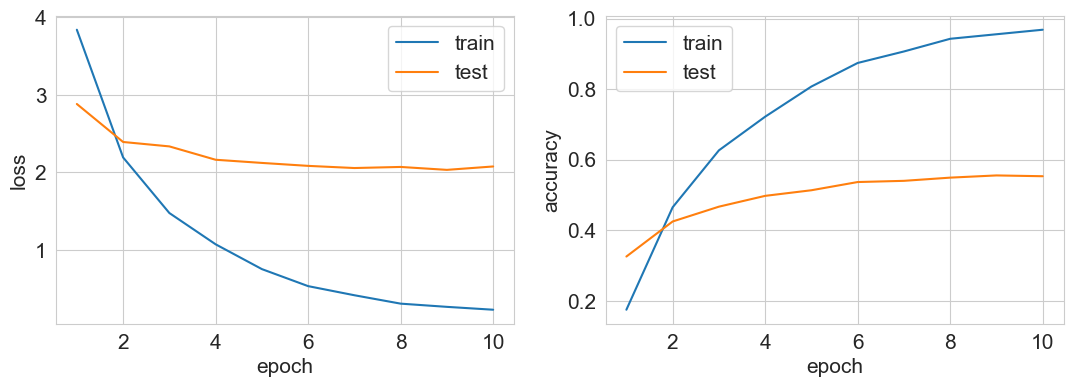

In [60]:
train_losses, test_losses, train_accuracies, test_accuracies = train(
    model, optimizer, scheduler, criterion, train_loader, test_loader, num_epochs
)

In [61]:
print("final test accuracy:", test_accuracies[-1])

final test accuracy: 0.5533484676503972


## Готовая архитектура

In [62]:
from torchvision.models import resnet18

num_epochs = 10
model = resnet18(num_classes=len(train_dataset.classes)).to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
criterion = torch.nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, num_epochs)

In [63]:
sum(param.numel() for param in model.parameters())

11253462

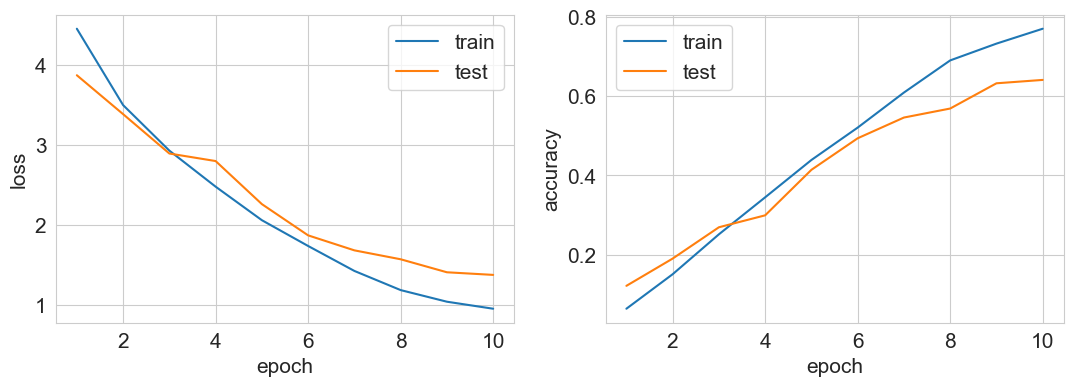

In [64]:
train_losses, test_losses, train_accuracies, test_accuracies = train(
    model, optimizer, scheduler, criterion, train_loader, test_loader, num_epochs
)

In [65]:
print("final test accuracy:", test_accuracies[-1])

final test accuracy: 0.6407491486946651


## Добавляем аугментации

In [66]:
train_transform = T.Compose([
    T.RandomResizedCrop(224, scale=(0.7, 1.0)),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    normalize,
])

In [67]:
train_dataset.transform = train_transform
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=True, num_workers=2)

In [68]:
model = resnet18(num_classes=len(train_dataset.classes)).to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
criterion = torch.nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, num_epochs)

In [69]:
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

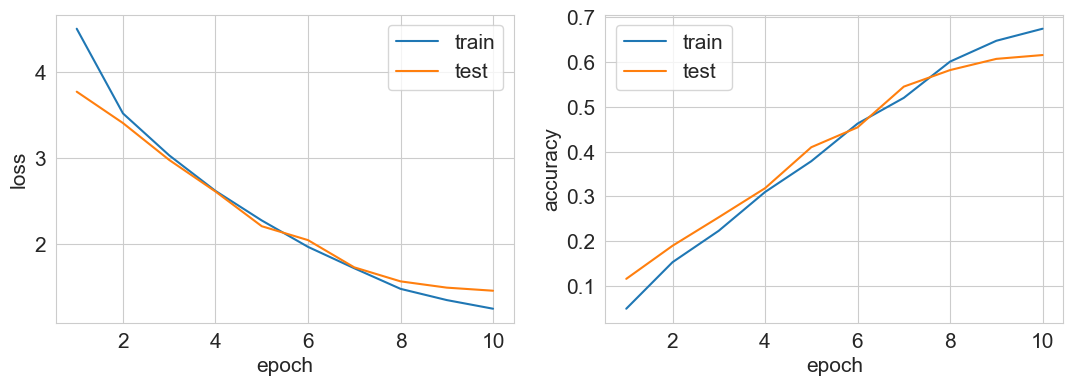

In [70]:
num_epochs = 10
train_losses, test_losses, train_accuracies, test_accuracies = train(
    model, optimizer, scheduler, criterion, train_loader, test_loader, num_epochs
)

In [71]:
print("final test accuracy:", test_accuracies[-1])

final test accuracy: 0.6152099886492622


## Finetune

In [72]:
model = resnet18(pretrained=True).to(device)
model.fc = torch.nn.Linear(512, len(train_dataset.classes))
model = model.to(device)

optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
criterion = torch.nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, num_epochs)

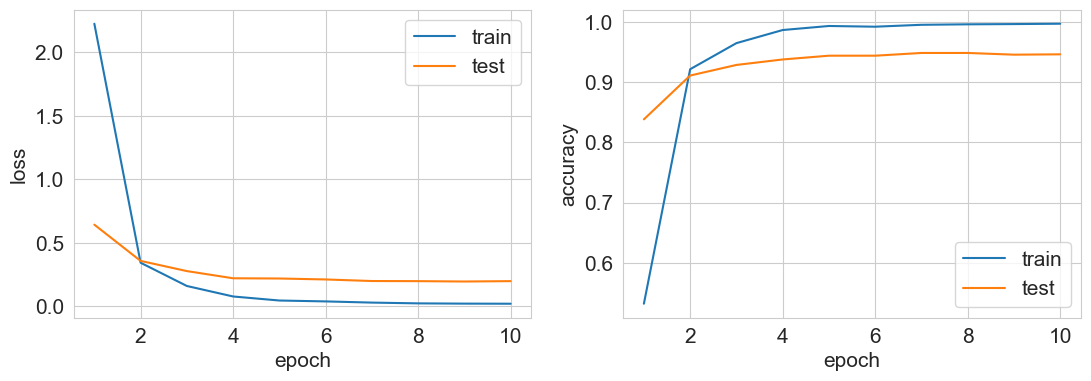

In [73]:
train_losses, test_losses, train_accuracies, test_accuracies = train(
    model, optimizer, scheduler, criterion, train_loader, test_loader, num_epochs
)

In [74]:
print("final test accuracy:", test_accuracies[-1])

final test accuracy: 0.9460839954597049


## Linear Probing

In [75]:
model = resnet18(pretrained=True).to(device)
model.fc = torch.nn.Linear(512, len(train_dataset.classes))
model = model.to(device)

for param in model.parameters():
    param.requires_grad = False
for param in model.fc.parameters():
    param.requires_grad = True

optimizer = torch.optim.SGD([param for param in model.parameters() if param.requires_grad], lr=0.01, momentum=0.9)
criterion = torch.nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, num_epochs)

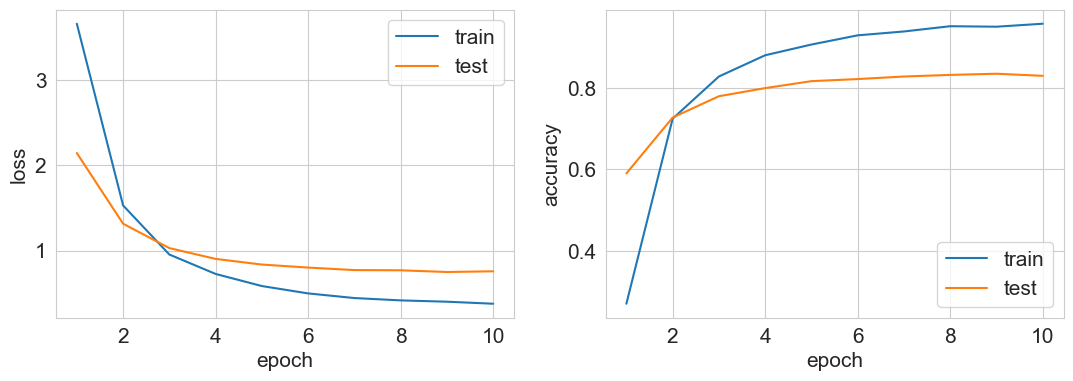

In [76]:
train_losses, test_losses, train_accuracies, test_accuracies = train(
    model, optimizer, scheduler, criterion, train_loader, test_loader, num_epochs
)

In [77]:
print("final test accuracy:", test_accuracies[-1])

final test accuracy: 0.8291713961407492
